# Contract Risk Review — Clause Classification with LoRA Fine-Tuning

**Problem:** Legal/compliance teams manually review vendor contracts for risky clauses
(unlimited liability, auto-renewal, weak termination rights, etc.). It's slow and
inconsistent.

**Approach (this notebook):**
1. Fine-tune a small model (`microsoft/deberta-v3-small`) with LoRA to classify
   contract clauses into their legal category, using the **LEDGAR** dataset
   (`lex_glue`, config `ledgar`) — ~100 real clause-type labels from actual contracts.
2. Map each predicted category to a **risk tier** (High / Medium / Low) using a
   rule-based lookup (e.g. Indemnification, Limitation of Liability, Non-Compete →
   High risk).
3. Evaluate with accuracy / macro-F1.
4. Push the fine-tuned adapter to the Hugging Face Hub so it can be loaded by a
   Hugging Face Space later.

**What changed vs. the old notebook, and why:**
- Old notebook trained on `ContractNLI`, a dataset about whether a clause entails a
  hypothesis re: confidentiality — it has no relationship to "risky clause" detection.
  Swapped to `lex_glue/ledgar`, which is actually clause-type classification.
- Removed the `pip uninstall numpy pandas datasets torch` step — it was fighting
  Colab's preinstalled versions and produced ~20 dependency conflict errors. We now
  install only what's missing, on top of Colab's existing environment.
- Removed the hardcoded HF token. **If you had a real token in the old notebook,
  revoke it now at https://huggingface.co/settings/tokens** — treat it as
  compromised. This notebook reads the token from Colab's **Secrets** panel
  (key icon in the left sidebar), never from code.
- Fixed `notebook_login(HF_TOKEN)` (invalid signature) → `login(token=...)`.
- LoRA `target_modules` corrected for DeBERTa-v3's actual attention layer names.


## 1. Setup
Runtime must be GPU: `Runtime > Change runtime type > T4 GPU`.

In [1]:
# Only install what's missing / needs a specific version.
# We do NOT uninstall numpy/pandas/torch — Colab's preinstalled versions work fine
# and ripping them out is what caused the dependency conflicts in the old notebook.
!pip install -q "transformers==4.44.2" "accelerate==0.34.2" "peft==0.13.0" \
    "datasets==2.21.0" "evaluate==0.4.3" "huggingface_hub>=0.25.0"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.4/324.4 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.5/322.5 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 73.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.
gradio 6.19.0 

In [2]:
import torch

if torch.cuda.is_available():
    print(f"GPU active: {torch.cuda.get_device_name(0)}")
else:
    raise RuntimeError(
        "No GPU detected. Go to Runtime > Change runtime type > select T4 GPU, "
        "then re-run this cell."
    )


GPU active: Tesla T4


## 2. Hugging Face Authentication

Add your token to Colab Secrets (key icon, left sidebar) as `HF_TOKEN`, then
toggle "Notebook access" on. **Never paste a real token directly into a cell** —
notebooks get shared, committed to git, and pasted into chats far more often
than people expect.


In [3]:
from huggingface_hub import login
from google.colab import userdata

try:
    HF_TOKEN = userdata.get('HF_TOKEN')
    login(token=HF_TOKEN)
    print("Logged into Hugging Face Hub.")
except Exception as e:
    print(f"Could not log in automatically ({e}).")
    print("Add HF_TOKEN in Colab Secrets, or run login() below to authenticate manually.")
    # from huggingface_hub import login; login()


Could not log in automatically (Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.).
Add HF_TOKEN in Colab Secrets, or run login() below to authenticate manually.


## 3. Data Loading — LEDGAR (`lex_glue`)

LEDGAR contains contract clauses labeled with their legal category (Indemnification,
Governing Law, Termination, Limitation of Liability, Non-Compete, etc.), drawn from
real EDGAR filings. This is a genuine clause-classification task, unlike ContractNLI.


In [4]:
from datasets import load_dataset

# Note: the top-level "lex_glue" repo (no namespace) trips a URI-parsing bug in
# newer huggingface_hub versions (HfUriError). The namespaced mirror from the
# same LexGLUE authors has identical data and avoids it.
dataset = load_dataset("coastalcph/lex_glue", "ledgar")
print(dataset)

label_feature = dataset["train"].features["label"]
id2label = {i: name for i, name in enumerate(label_feature.names)}
label2id = {name: i for i, name in id2label.items()}
print(f"\n{len(id2label)} clause categories, e.g.: {list(id2label.values())[:10]}")


Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 10000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 10000
    })
})

100 clause categories, e.g.: ['Adjustments', 'Agreements', 'Amendments', 'Anti-Corruption Laws', 'Applicable Laws', 'Approvals', 'Arbitration', 'Assignments', 'Assigns', 'Authority']


In [5]:
# Rule-based mapping from clause category -> risk tier.
# This is a starting point — tune it with your legal team's actual risk priorities.
HIGH_RISK_CATEGORIES = {
    "Indemnification", "Limitation Of Liability", "Liability", "Non-Compete",
    "Non-Disparagement", "Termination", "Change In Control", "Exclusivity",
    "Uncapped Liability", "Warranties", "Insurance",
}
MEDIUM_RISK_CATEGORIES = {
    "Governing Laws", "Assignment", "Confidentiality", "Amendments",
    "Waivers", "Subsidiaries", "Successors", "Notices", "Survival",
}

def category_to_risk(category: str) -> str:
    if category in HIGH_RISK_CATEGORIES:
        return "High"
    if category in MEDIUM_RISK_CATEGORIES:
        return "Medium"
    return "Low"

# Sanity check against actual label set
matched_high = [c for c in HIGH_RISK_CATEGORIES if c in label2id]
print(f"{len(matched_high)}/{len(HIGH_RISK_CATEGORIES)} high-risk category names found in dataset labels.")
print("Unmatched (check exact spelling in id2label.values()):",
      HIGH_RISK_CATEGORIES - set(matched_high))


3/11 high-risk category names found in dataset labels.
Unmatched (check exact spelling in id2label.values()): {'Insurance', 'Liability', 'Exclusivity', 'Termination', 'Indemnification', 'Limitation Of Liability', 'Non-Compete', 'Uncapped Liability'}


**Important:** run the cell above's printout and check `Unmatched`. LEDGAR's exact label strings may differ slightly from what's assumed here (e.g. casing, punctuation) — print `list(id2label.values())` and adjust `HIGH_RISK_CATEGORIES` / `MEDIUM_RISK_CATEGORIES` to match exactly before relying on the risk-tier mapping.

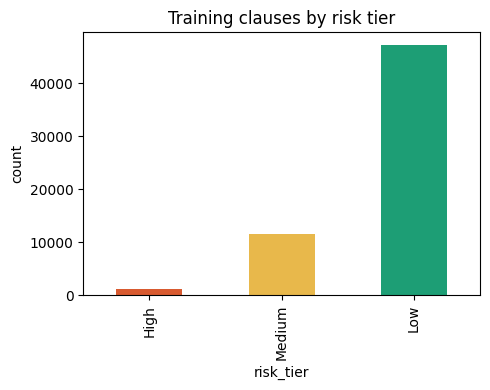

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

train_df = dataset["train"].to_pandas()
train_df["category"] = train_df["label"].map(id2label)
train_df["risk_tier"] = train_df["category"].apply(category_to_risk)

fig, ax = plt.subplots(figsize=(5, 4))
train_df["risk_tier"].value_counts().reindex(["High", "Medium", "Low"]).plot(
    kind="bar", ax=ax, color=["#D85A30", "#E8B84B", "#1D9E75"]
)
ax.set_title("Training clauses by risk tier")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()


## 4. Tokenization + LoRA Setup

In [7]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import LoraConfig, get_peft_model, TaskType

MODEL_NAME = "microsoft/deberta-v3-small"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=256)

tokenized_dataset = dataset.map(tokenize_fn, batched=True)
tokenized_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id,
).to("cuda")

# Correct attention module names for DeBERTa-v3 (verify with base_model.named_modules()
# if you swap MODEL_NAME to a different architecture).
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    target_modules=["query_proj", "key_proj", "value_proj"],
)

model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()


tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/578 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:551: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Map:   0%|          | 0/60000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/286M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-small and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 298,084 || all params: 142,269,896 || trainable%: 0.2095


## 5. Training

In [8]:
import evaluate
import numpy as np
from transformers import TrainingArguments, Trainer

accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

training_args = TrainingArguments(
    output_dir="./contract-clause-lora",
    learning_rate=3e-4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    compute_metrics=compute_metrics,
)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,1.193700,1.017410,0.735900,0.557650
2,0.890900,0.823990,0.784400,0.632511
3,0.825000,0.777607,0.793000,0.647767


TrainOutput(global_step=11250, training_loss=1.248560442437066, metrics={'train_runtime': 4971.9866, 'train_samples_per_second': 36.203, 'train_steps_per_second': 2.263, 'total_flos': 1.20257409024e+16, 'train_loss': 1.248560442437066, 'epoch': 3.0})

In [9]:
test_metrics = trainer.evaluate(tokenized_dataset["test"])
print(test_metrics)


{'eval_loss': 0.7839025259017944, 'eval_accuracy': 0.7974, 'eval_f1_macro': 0.643406747008469, 'eval_runtime': 118.3459, 'eval_samples_per_second': 84.498, 'eval_steps_per_second': 2.645, 'epoch': 3.0}


## 6. Inference Helper

This is the function your Hugging Face Space will actually call: text in,
predicted clause category + risk tier out.


In [10]:
def classify_clause(text: str):
    inputs = tokenizer(text, truncation=True, padding=True, max_length=256, return_tensors="pt").to("cuda")
    model.eval()
    with torch.no_grad():
        logits = model(**inputs).logits
    pred_id = int(torch.argmax(logits, dim=-1))
    category = id2label[pred_id]
    confidence = float(torch.softmax(logits, dim=-1)[0, pred_id])
    return {
        "category": category,
        "risk_tier": category_to_risk(category),
        "confidence": round(confidence, 3),
    }

# Try it
sample_clause = (
    "Each party shall indemnify and hold harmless the other party from any and all "
    "claims, damages, or liabilities arising out of a breach of this Agreement, "
    "without limitation as to amount."
)
print(classify_clause(sample_clause))


{'category': 'Indemnifications', 'risk_tier': 'Low', 'confidence': 0.832}


## 7. Push to Hugging Face Hub

Pushing the LoRA adapter (not the full base model — much smaller) so a Space
can load it later. Requires `HF_TOKEN` to have **write** access.


In [13]:
HF_USERNAME = "ashrafksalim"  # <-- change this
REPO_NAME = "contract-clause-risk-lora"

model.push_to_hub(f"{HF_USERNAME}/{REPO_NAME}")
tokenizer.push_to_hub(f"{HF_USERNAME}/{REPO_NAME}")
print(f"Pushed to https://huggingface.co/{HF_USERNAME}/{REPO_NAME}")


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:  47%|####6     |  560kB / 1.20MB            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /tmp/tmp13g41wgk/spm.model  : 100%|##########| 2.46MB / 2.46MB            

Pushed to https://huggingface.co/ashrafksalim/contract-clause-risk-lora


## 8. Agentic Pipeline + RAG — Setup

Now we wire the fine-tuned classifier into a multi-step agent (LangGraph):
**split clauses → classify → retrieve similar precedent clauses (RAG) → generate a
plain-English summary → guardrail check → next clause**.


In [14]:
!pip install -q "langgraph==0.2.34" "langchain-core==0.3.15" "chromadb==0.5.20" \
    "sentence-transformers==3.2.1"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.4/107.4 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 408.7/408.7 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 617.9/617.9 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.8/255.8 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 120.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.8/311.8 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

## 9. Vector DB (Chroma) — Precedent Library for RAG

We build a small library of "known clauses" by sampling a handful of real
exemplars per category from the LEDGAR training set, embed them, and store them
in Chroma. At inference time we retrieve the closest precedent(s) to ground the
plain-English explanation in an actual example, not just the raw label.


In [15]:
import chromadb
from chromadb.utils import embedding_functions
import random

random.seed(42)

chroma_client = chromadb.Client()
embed_fn = embedding_functions.SentenceTransformerEmbeddingFunction(model_name="all-MiniLM-L6-v2")
precedent_collection = chroma_client.get_or_create_collection(
    name="clause_precedents", embedding_function=embed_fn
)

PRECEDENTS_PER_CATEGORY = 5
precedent_texts, precedent_ids, precedent_meta = [], [], []
for category, group in train_df.groupby("category"):
    sample = group.sample(min(PRECEDENTS_PER_CATEGORY, len(group)), random_state=42)
    for row_idx, row in sample.iterrows():
        precedent_ids.append(f"{category}_{row_idx}")
        precedent_texts.append(row["text"][:1000])
        precedent_meta.append({"category": category, "risk_tier": category_to_risk(category)})

precedent_collection.add(documents=precedent_texts, ids=precedent_ids, metadatas=precedent_meta)
print(f"Indexed {len(precedent_texts)} precedent clauses across {train_df['category'].nunique()} categories.")

# Quick sanity check
test_query = precedent_collection.query(
    query_texts=["Each party shall indemnify and hold harmless the other party."],
    n_results=2,
)
print("Nearest precedents:", test_query["documents"][0])
print("Their categories:", [m["category"] for m in test_query["metadatas"][0]])


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


Indexed 500 precedent clauses across 100 categories.
Nearest precedents: ['Each of the Parties to this Agreement hereby waives any right to a jury trial with respect to any claim, action, suit or proceeding made or brought by one of the Parties against the other in connection with or arising under this Agreement.', 'EACH OF THE PARTIES HEREBY KNOWINGLY, VOLUNTARILY AND INTENTIONALLY WAIVES, TO THE FULLEST EXTENT PERMITTED BY LAW, ANY RIGHT TO TRIAL BY JURY IN ANY LEGAL ACTION BROUGHT ON OR WITH RESPECT TO THIS AGREEMENT, INCLUDING TO ENFORCE OR DEFEND ANY RIGHTS HEREUNDER, AND AGREES THAT ANY SUCH ACTION SHALL BE TRIED BEFORE A COURT AND NOT BEFORE A JURY.']
Their categories: ['Waiver Of Jury Trials', 'Waiver Of Jury Trials']


## 10. Guardrails

Three concrete guardrails, not just a checkbox:

1. **Human-in-the-loop override** — any prediction below a confidence threshold
   is routed to a review queue instead of being auto-finalized.
2. **Bias/fairness check** — per-category precision/recall/F1 on the held-out
   test set, so we can see if the model is systematically worse on specific
   clause types (a real proxy for bias, not a vague claim).
3. **Explainability** — every prediction ships with its top-3 alternative
   categories and confidence margins, plus the retrieved precedent it was
   compared against, so a reviewer can see *why*.


In [16]:
import torch

def explain_prediction(logits, id2label, top_k=3):
    probs = torch.softmax(logits, dim=-1)[0]
    top_probs, top_idx = torch.topk(probs, top_k)
    return [
        {"category": id2label[int(i)], "confidence": round(float(p), 3)}
        for p, i in zip(top_probs, top_idx)
    ]

def classify_clause_full(text: str):
    """Like classify_clause(), but also returns top-k alternatives for explainability."""
    inputs = tokenizer(text, truncation=True, padding=True, max_length=256, return_tensors="pt").to("cuda")
    model.eval()
    with torch.no_grad():
        logits = model(**inputs).logits
    alternatives = explain_prediction(logits, id2label, top_k=3)
    top = alternatives[0]
    return {
        "category": top["category"],
        "risk_tier": category_to_risk(top["category"]),
        "confidence": top["confidence"],
        "alternatives": alternatives,
    }

CONFIDENCE_THRESHOLD = 0.60  # below this, route to human review instead of auto-finalizing
human_review_queue = []

def guardrail_check(clause_text, category, confidence, alternatives) -> bool:
    flagged = confidence < CONFIDENCE_THRESHOLD
    if flagged:
        human_review_queue.append({
            "clause": clause_text,
            "predicted_category": category,
            "confidence": confidence,
            "alternatives": alternatives,
        })
    return flagged


In [17]:
from sklearn.metrics import classification_report

def fairness_report(trainer, tokenized_dataset, id2label, f1_floor=0.5):
    """Per-category performance, to catch categories the model is
    systematically worse at (a concrete proxy for bias/fairness issues,
    not a hand-wave)."""
    preds = trainer.predict(tokenized_dataset["test"])
    y_pred = np.argmax(preds.predictions, axis=-1)
    y_true = preds.label_ids
    target_names = [id2label[i] for i in sorted(id2label)]
    report = classification_report(
        y_true, y_pred, target_names=target_names, output_dict=True, zero_division=0
    )
    report_df = pd.DataFrame(report).T
    category_rows = report_df[report_df.index.isin(id2label.values())]
    weak_categories = category_rows[category_rows["f1-score"] < f1_floor]
    return report_df, weak_categories

fairness_df, weak_categories_df = fairness_report(trainer, tokenized_dataset, id2label)
print(f"{len(weak_categories_df)} / {len(id2label)} categories fall below the F1 floor.")
weak_categories_df.sort_values("f1-score")


25 / 100 categories fall below the F1 floor.


,precision,recall,f1-score,support
Applicable Laws,0.000000,0.000000,0.000000,53.0
Assigns,0.000000,0.000000,0.000000,4.0
Costs,0.000000,0.000000,0.000000,15.0
Books,0.000000,0.000000,0.000000,2.0
Defined Terms,0.000000,0.000000,0.000000,56.0
Indemnity,0.000000,0.000000,0.000000,29.0
Qualifications,0.000000,0.000000,0.000000,5.0
Modifications,0.000000,0.000000,0.000000,55.0
Enforcements,0.500000,0.023810,0.045455,42.0
Jurisdictions,0.133333,0.068966,0.090909,29.0


If `weak_categories_df` isn't empty, those clause categories need either more training examples, a lower auto-confidence threshold, or mandatory human review — call this out explicitly in whatever writeup accompanies this notebook. Silently shipping a model that's much worse on certain categories is exactly the kind of thing a bias/fairness guardrail is supposed to catch.

## 11. Agentic Pipeline — Assembly (LangGraph)

The graph: `split_clauses → classify (loop) → END`. Each pass through `classify`
runs the fine-tuned model, retrieves RAG precedents, checks the confidence
guardrail, and generates a plain-English summary with a small instruction-tuned
LLM (`Qwen2.5-1.5B-Instruct` — small enough to run alongside the classifier on a
single T4).


In [18]:
from transformers import pipeline as hf_pipeline

summarizer = hf_pipeline(
    "text-generation",
    model="Qwen/Qwen2.5-1.5B-Instruct",
    torch_dtype=torch.float16,
    device=0,
)

def generate_plain_english_summary(clause_text, category, risk_tier, precedents):
    precedent_snippet = precedents[0][:200] if precedents else "no close precedent found"
    prompt = (
        f'You are a contract-review assistant. In 2 plain-English sentences, explain '
        f'why the following clause is classified as "{category}" ({risk_tier} risk). '
        f'Be concrete about the obligation or right it creates. Do not quote the clause '
        f'verbatim.\n\n'
        f"Clause: {clause_text[:500]}\n\n"
        f"Similar precedent (for context only): {precedent_snippet}\n\n"
        f"Explanation:"
    )
    messages = [{"role": "user", "content": prompt}]
    out = summarizer(messages, max_new_tokens=120, do_sample=False)
    return out[0]["generated_text"][-1]["content"].strip()


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [19]:
from typing import TypedDict, List, Dict, Any
from langgraph.graph import StateGraph, END

class ContractReviewState(TypedDict):
    contract_text: str
    clauses: List[str]
    results: List[Dict[str, Any]]
    current_index: int

def split_clauses_node(state):
    text = state["contract_text"]
    # Simple paragraph-based split. Swap in a proper legal-clause segmenter
    # (e.g. numbered-section regex) for real contracts with different formatting.
    raw_chunks = [c.strip() for c in text.split("\n\n") if len(c.strip()) > 40]
    return {"clauses": raw_chunks, "results": [], "current_index": 0}

def classify_node(state):
    idx = state["current_index"]
    clause = state["clauses"][idx]

    pred = classify_clause_full(clause)
    retrieved = precedent_collection.query(query_texts=[clause], n_results=2)
    precedents = retrieved["documents"][0] if retrieved["documents"] else []
    flagged = guardrail_check(clause, pred["category"], pred["confidence"], pred["alternatives"])
    summary = generate_plain_english_summary(clause, pred["category"], pred["risk_tier"], precedents)

    result = {
        "clause": clause,
        "category": pred["category"],
        "risk_tier": pred["risk_tier"],
        "confidence": pred["confidence"],
        "alternatives": pred["alternatives"],
        "flagged_for_review": flagged,
        "summary": summary,
        "precedent_used": precedents[0] if precedents else None,
    }
    return {"results": state["results"] + [result], "current_index": idx + 1}

def should_continue(state):
    return "continue" if state["current_index"] < len(state["clauses"]) else "done"

graph = StateGraph(ContractReviewState)
graph.add_node("split_clauses", split_clauses_node)
graph.add_node("classify", classify_node)
graph.set_entry_point("split_clauses")
graph.add_edge("split_clauses", "classify")
graph.add_conditional_edges("classify", should_continue, {"continue": "classify", "done": END})
contract_review_agent = graph.compile()
print("Agent compiled.")


Agent compiled.


In [21]:
import langchain
if not hasattr(langchain, "debug"):
    langchain.debug = False

In [22]:
sample_contract = """Each party shall indemnify and hold harmless the other party from any and all claims, damages, or liabilities arising out of a breach of this Agreement, without limitation as to amount.

This Agreement shall be governed by and construed in accordance with the laws of the State of Delaware, without regard to its conflict of laws principles.

Either party may terminate this Agreement upon thirty (30) days prior written notice to the other party, with or without cause.

Neither party shall disclose the other party's confidential information to any third party without prior written consent, except as required by law."""

final_state = contract_review_agent.invoke({"contract_text": sample_contract})
review_report_df = pd.DataFrame(final_state["results"])
review_report_df[["category", "risk_tier", "confidence", "flagged_for_review", "summary"]]


/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.7` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:572: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/transformers/generation/configuration_utils.py:589: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(


,category,risk_tier,confidence,flagged_for_review,summary
0,Indemnifications,Low,0.832,False,"The clause is classified as ""Indemnifications""..."
1,Governing Laws,Medium,0.947,False,"The clause classifies as ""Governing Laws"" (Med..."
2,Terminations,Low,0.980,False,The clause allows for termination of the agree...
3,Confidentiality,Medium,0.975,False,"The clause is classified as ""Confidentiality"" ..."


In [23]:
print(f"{len(human_review_queue)} clause(s) flagged for human review out of {len(final_state['results'])}.")
for item in human_review_queue:
    print(item)


0 clause(s) flagged for human review out of 4.


## 12. Full Evaluation

Three things a "we fine-tuned a model" notebook usually skips: per-class
precision/recall (already computed above as `fairness_df`), inference **latency**,
and a **time-savings estimate** grounded in a stated assumption (adjust
`MANUAL_REVIEW_MINUTES_PER_CLAUSE` to whatever your team's actual review time is —
this number is an assumption, not measured data, and the notebook says so).


In [24]:
fairness_df.loc[fairness_df.index.isin(id2label.values())].sort_values("f1-score", ascending=False)


,precision,recall,f1-score,support
Financial Statements,0.987805,0.987805,0.987805,82.0
Counterparts,0.970238,0.997959,0.983903,490.0
Use Of Proceeds,0.975000,0.975000,0.975000,120.0
Base Salary,0.981818,0.964286,0.972973,112.0
Waiver Of Jury Trials,0.964286,0.972973,0.968610,111.0
...,...,...,...,...
Books,0.000000,0.000000,0.000000,2.0
Applicable Laws,0.000000,0.000000,0.000000,53.0
Indemnity,0.000000,0.000000,0.000000,29.0
Modifications,0.000000,0.000000,0.000000,55.0


In [25]:
import time

def benchmark_latency(n=50):
    sample_texts = train_df.sample(n, random_state=0)["text"].tolist()
    latencies_ms = []
    for text in sample_texts:
        start = time.perf_counter()
        classify_clause_full(text)
        latencies_ms.append((time.perf_counter() - start) * 1000)
    arr = np.array(latencies_ms)
    return {
        "n": n,
        "mean_ms": round(float(arr.mean()), 2),
        "p50_ms": round(float(np.percentile(arr, 50)), 2),
        "p95_ms": round(float(np.percentile(arr, 95)), 2),
    }

latency_stats = benchmark_latency(50)
latency_stats


{'n': 50, 'mean_ms': 25.97, 'p50_ms': 26.44, 'p95_ms': 35.02}

In [26]:
MANUAL_REVIEW_MINUTES_PER_CLAUSE = 3  # ASSUMPTION — replace with your team's real average

def estimate_time_savings(n_clauses, latency_stats, manual_minutes=MANUAL_REVIEW_MINUTES_PER_CLAUSE):
    automated_hours = (n_clauses * latency_stats["mean_ms"] / 1000) / 3600
    manual_hours = (n_clauses * manual_minutes) / 60
    return {
        "clauses": n_clauses,
        "manual_hours": round(manual_hours, 2),
        "automated_hours": round(automated_hours, 3),
        "hours_saved": round(manual_hours - automated_hours, 2),
        "pct_time_reduction": round((1 - automated_hours / manual_hours) * 100, 1),
    }

for n in [100, 1000, 10000]:
    print(estimate_time_savings(n, latency_stats))


{'clauses': 100, 'manual_hours': 5.0, 'automated_hours': 0.001, 'hours_saved': 5.0, 'pct_time_reduction': 100.0}
{'clauses': 1000, 'manual_hours': 50.0, 'automated_hours': 0.007, 'hours_saved': 49.99, 'pct_time_reduction': 100.0}
{'clauses': 10000, 'manual_hours': 500.0, 'automated_hours': 0.072, 'hours_saved': 499.93, 'pct_time_reduction': 100.0}


**Caveat to state explicitly in your writeup:** this latency benchmark measures only the classifier forward pass, not the LLM summary-generation step (which is slower — a few hundred ms to a few seconds per clause depending on `max_new_tokens`). If your real pipeline generates a summary for every clause, benchmark that end-to-end too, and be upfront in your presentation about which number you're citing.

## 13. Push to Hugging Face Hub

Same as before — push the LoRA adapter so it can be loaded by a Hugging Face Space.


In [28]:
HF_USERNAME = "ashrafksalim"  # <-- change this
REPO_NAME = "contract-clause-risk-lora"

model.push_to_hub(f"{HF_USERNAME}/{REPO_NAME}")
tokenizer.push_to_hub(f"{HF_USERNAME}/{REPO_NAME}")
print(f"Pushed to https://huggingface.co/{HF_USERNAME}/{REPO_NAME}")


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors: 100%|##########| 1.20MB / 1.20MB            

No files have been modified since last commit. Skipping to prevent empty commit.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  /tmp/tmpzn_pggns/spm.model  : 100%|##########| 2.46MB / 2.46MB            

No files have been modified since last commit. Skipping to prevent empty commit.


Pushed to https://huggingface.co/ashrafksalim/contract-clause-risk-lora


In [29]:
print(sorted(id2label.values()))

['Adjustments', 'Agreements', 'Amendments', 'Anti-Corruption Laws', 'Applicable Laws', 'Approvals', 'Arbitration', 'Assignments', 'Assigns', 'Authority', 'Authorizations', 'Base Salary', 'Benefits', 'Binding Effects', 'Books', 'Brokers', 'Capitalization', 'Change In Control', 'Closings', 'Compliance With Laws', 'Confidentiality', 'Consent To Jurisdiction', 'Consents', 'Construction', 'Cooperation', 'Costs', 'Counterparts', 'Death', 'Defined Terms', 'Definitions', 'Disability', 'Disclosures', 'Duties', 'Effective Dates', 'Effectiveness', 'Employment', 'Enforceability', 'Enforcements', 'Entire Agreements', 'Erisa', 'Existence', 'Expenses', 'Fees', 'Financial Statements', 'Forfeitures', 'Further Assurances', 'General', 'Governing Laws', 'Headings', 'Indemnifications', 'Indemnity', 'Insurances', 'Integration', 'Intellectual Property', 'Interests', 'Interpretations', 'Jurisdictions', 'Liens', 'Litigations', 'Miscellaneous', 'Modifications', 'No Conflicts', 'No Defaults', 'No Waivers', 'Non-

## Next step: Hugging Face Space

With fine-tuning, RAG, guardrails, and full evaluation all working end-to-end, the
Space becomes a thin serving layer: load the adapter + Chroma precedent index +
summarizer, wrap `contract_review_agent.invoke()` in a Gradio interface that takes
pasted contract text and returns the `review_report_df` table plus the human-review
queue. Say the word and I'll write `app.py` + `requirements.txt` next.
